# RNN Testing - Online and Offline Framework
### Anaerobic Digestion of Olive Mill Waste — Crete Case Study

---

## results from RNN Training and retrain

**1st training run - RNNModel(5, 20, 1, 3):**

the 1st RNN training run achieved a final MSE loss of 0.000138, which is
11 times lower than the best ANN loss of 0.001549. the model converged
fully within 20 epochs and produced R² values of 0.9993 for both dS/dt
and dM/dt, and 0.9977 for dpH/dt. residual means were near 0 across
all 3 outputs

**K-Fold search:**

the K-Fold search over 45 combinations identified hidden_dim=30, lr=0.001,
batch=25 as the best combination, with avg validation loss of 0.000102 and
std of 0.000016 (the lowest std of the entire search), indicating stable
generalisation across all folds

**retrain: RNNModel(5, 30, 1, 3):**

the retrain with hidden_dim=30 produced a final loss of 0.0001371, compared
to 0.0001380 for the 1st run, an improvement of 0.7% only. R² values
changed by at most 0.0001 in either direction. residual means were a little
larger than the 1st run, with dS/dt showing a small systematic negative
bias of -0.005700

**decision: the 1st run model is used for testing**

the retrain showed capacity saturation, the RNN has learned
everything it could from this dataset at hidden_dim=20. increasing to
hidden_dim=30 nearly doubles the parameter count (603 to 1203) with no
accuracy gain and slightly worse residual behaviour. it looks like the simpler
model is the best scientific choice. this can be interpreted as: the
digester dynamics can be fully captured by a single-layer RNN with 20
hidden units and a 12-step input sequence

The model loaded below is `RNN_olive_mill.pt` — the first run model

---

## Purpose of this notebook

the trained RNN is tested on 4 simulation runs covering different
corners of the operating space. testing follows 2 frameworks:

**online:** the actual measured state is provided at each timestep. the model
predicts rates of change and Euler integration steps forward 1 day

**offline:** only day 0 is provided. each prediction becomes the input for
the next step, errors compound over 30 days

results are compared directly to the ANN testing results:
- ANN online mean MAPE: S=0.07%, M=0.06%, pH=0.00%
- ANN offline mean MAPE: S=0.45%, M=0.29%, pH=0.02%


## 1. Imports

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import openpyxl
from sklearn.preprocessing import StandardScaler
from scipy.integrate import odeint

print("torch version:", torch.__version__)

torch version: 2.11.0


## 2. Load Trained Model

In [2]:
class RNNModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, layer_dim, output_dim):
        super(RNNModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.layer_dim  = layer_dim
        self.rnn = nn.RNN(input_dim, hidden_dim, layer_dim,
                          batch_first=True, nonlinearity='tanh')
        self.fc  = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0  = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim)
        out, hn = self.rnn(x, h0.detach())
        out = self.fc(out[:, -1, :])
        return out

# load first run model, hidden_dim=20 chosen over retrain (capacity saturation)
seq_len    = 12
hidden_dim = 20

model = RNNModel(5, hidden_dim, 1, 3)
model.load_state_dict(torch.load('RNN_olive_mill.pt'))
model.eval()

print(f"model loaded: RNNModel(5, {hidden_dim}, 1, 3)")
print(f"parameters  : {sum(p.numel() for p in model.parameters())}")
print(f"seq_len     : {seq_len}")
print("mode        : eval")

model loaded: RNNModel(5, 20, 1, 3)
parameters  : 603
seq_len     : 12
mode        : eval


## 3. Reconstruct Scaler

In [3]:
scaler_mean  = np.load('scaler_mean.npy')
scaler_scale = np.load('scaler_scale.npy')

scaler = StandardScaler()
scaler.mean_  = scaler_mean
scaler.scale_ = scaler_scale
scaler.var_   = scaler_scale ** 2
scaler.n_features_in_ = 8

print("scaler reconstructed")
print("means: ", [round(m, 3) for m in scaler.mean_])

scaler reconstructed
means:  [np.float64(17.244), np.float64(6747.284), np.float64(7.109), np.float64(36.25), np.float64(3.333), np.float64(-0.928), np.float64(352.734), np.float64(-0.013)]


## 4. Generate Test Data

same 4 test conditions as ANN testing for direct comparison


In [4]:
k_h   = 0.08
Y_CH4 = 380.0
k_pH  = 0.003
S_ref = 2.0
pH_eq = 6.8

def f_T(T):   return np.exp(-0.07 * (T - 35.0))
def f_pH(pH): return 1.0 / (1.0 + np.exp(-2.0 * (pH - 6.5)))

def digester_ode(state, t, T, OLR):
    S, M, pH = state
    S   = max(S, 0.0)
    pH  = max(pH, pH_eq)
    r   = k_h * S * f_T(T) * f_pH(pH)
    return [-r, Y_CH4 * r, -k_pH * max(S - S_ref, 0.0) * (pH - pH_eq)]

t_span = np.linspace(0, 30, 31)

test_conditions = [
    (30.0, 15.0, 1.0, "T=30  S0=15  OLR=1  (low temp, low substrate)"),
    (35.0, 35.0, 3.0, "T=35  S0=35  OLR=3  (optimal conditions)"),
    (42.0, 55.0, 6.0, "T=42  S0=55  OLR=6  (high temp, high substrate)"),
    (30.0, 55.0, 6.0, "T=30  S0=55  OLR=6  (low temp, high substrate)"),
]

test_data = []
for T, S0, OLR, label in test_conditions:
    sol = odeint(digester_ode, [S0, 0.0, 7.4], t_span, args=(T, OLR))
    test_data.append({'T': T, 'S0': S0, 'OLR': OLR, 'label': label, 'trajectory': sol})
    print(f"generated: {label}")

generated: T=30  S0=15  OLR=1  (low temp, low substrate)
generated: T=35  S0=35  OLR=3  (optimal conditions)
generated: T=42  S0=55  OLR=6  (high temp, high substrate)
generated: T=30  S0=55  OLR=6  (low temp, high substrate)


## 5. MAPE Function

In [5]:
def MAPE(actual, predicted):
    mask  = np.abs(actual) > 1e-6
    if mask.sum() == 0:
        return np.nan
    return np.abs((actual[mask] - predicted[mask]) / actual[mask]).mean() * 100

## 6. Online Framework

**important difference from ANN online testing:**

the ANN received one row per timestep as input
the RNN requires a sequence of `seq_len` consecutive timesteps

for the online framework, at each step the RNN receives a window of the
last 12 actual measured states. for the 1st 12 steps where a full window
is not available, the available history is padded with the initial state


In [6]:
online_results = []

for run in test_data:
    T   = run['T']
    OLR = run['OLR']
    sol = run['trajectory']

    predicted_traj = [sol[0].copy()]

    for i in range(30):
        # build sequence: last seq_len actual states
        # if fewer than seq_len states available, pad with initial state
        window_start = max(0, i - seq_len + 1)
        window = sol[window_start : i + 1]   # actual states

        # pad to seq_len if needed
        if len(window) < seq_len:
            pad = np.tile(sol[0], (seq_len - len(window), 1))
            window = np.vstack([pad, window])

        # standardise (add dummy target cols)
        seq_raw = np.zeros((seq_len, 8))
        seq_raw[:, 0:3] = window        # S, M, pH
        seq_raw[:, 3]   = T             # temperature (constant)
        seq_raw[:, 4]   = OLR           # OLR (constant)
        seq_std = scaler.transform(seq_raw)[:, 0:5]   # (seq_len, 5)

        x_t = torch.tensor(seq_std, dtype=torch.float32).unsqueeze(0)  # (1, seq_len, 5)

        with torch.no_grad():
            rates_std = model(x_t).numpy()[0]

        # descale rates
        full_std = np.zeros(8)
        full_std[0:5] = seq_std[-1]    # last step inputs
        full_std[5:8] = rates_std
        full_phys = scaler.inverse_transform(full_std.reshape(1,-1))[0]
        dS, dM, dpH = full_phys[5], full_phys[6], full_phys[7]
        dpH = min(dpH, 0.0)

        S_next  = max(sol[i, 0] + dS,  0.0)
        M_next  = max(sol[i, 1] + dM,  0.0)
        pH_next = max(sol[i, 2] + dpH, pH_eq)

        predicted_traj.append(np.array([S_next, M_next, pH_next]))

    predicted_traj = np.array(predicted_traj)

    mape_S  = MAPE(sol[1:, 0], predicted_traj[1:, 0])
    mape_M  = MAPE(sol[1:, 1], predicted_traj[1:, 1])
    mape_pH = MAPE(sol[1:, 2], predicted_traj[1:, 2])

    online_results.append({
        'label': run['label'], 'actual': sol, 'predicted': predicted_traj,
        'mape_S': mape_S, 'mape_M': mape_M, 'mape_pH': mape_pH,
    })

    print(f"{run['label']}")
    print(f"  MAPE S:   {mape_S:.2f}%")
    print(f"  MAPE M:   {mape_M:.2f}%")
    print(f"  MAPE pH:  {mape_pH:.2f}%")
    print()

T=30  S0=15  OLR=1  (low temp, low substrate)
  MAPE S:   0.47%
  MAPE M:   1.81%
  MAPE pH:  0.01%

T=35  S0=35  OLR=3  (optimal conditions)
  MAPE S:   0.33%
  MAPE M:   2.31%
  MAPE pH:  0.04%

T=42  S0=55  OLR=6  (high temp, high substrate)
  MAPE S:   0.17%
  MAPE M:   2.14%
  MAPE pH:  0.10%

T=30  S0=55  OLR=6  (low temp, high substrate)
  MAPE S:   1.25%
  MAPE M:   4.78%
  MAPE pH:  0.07%



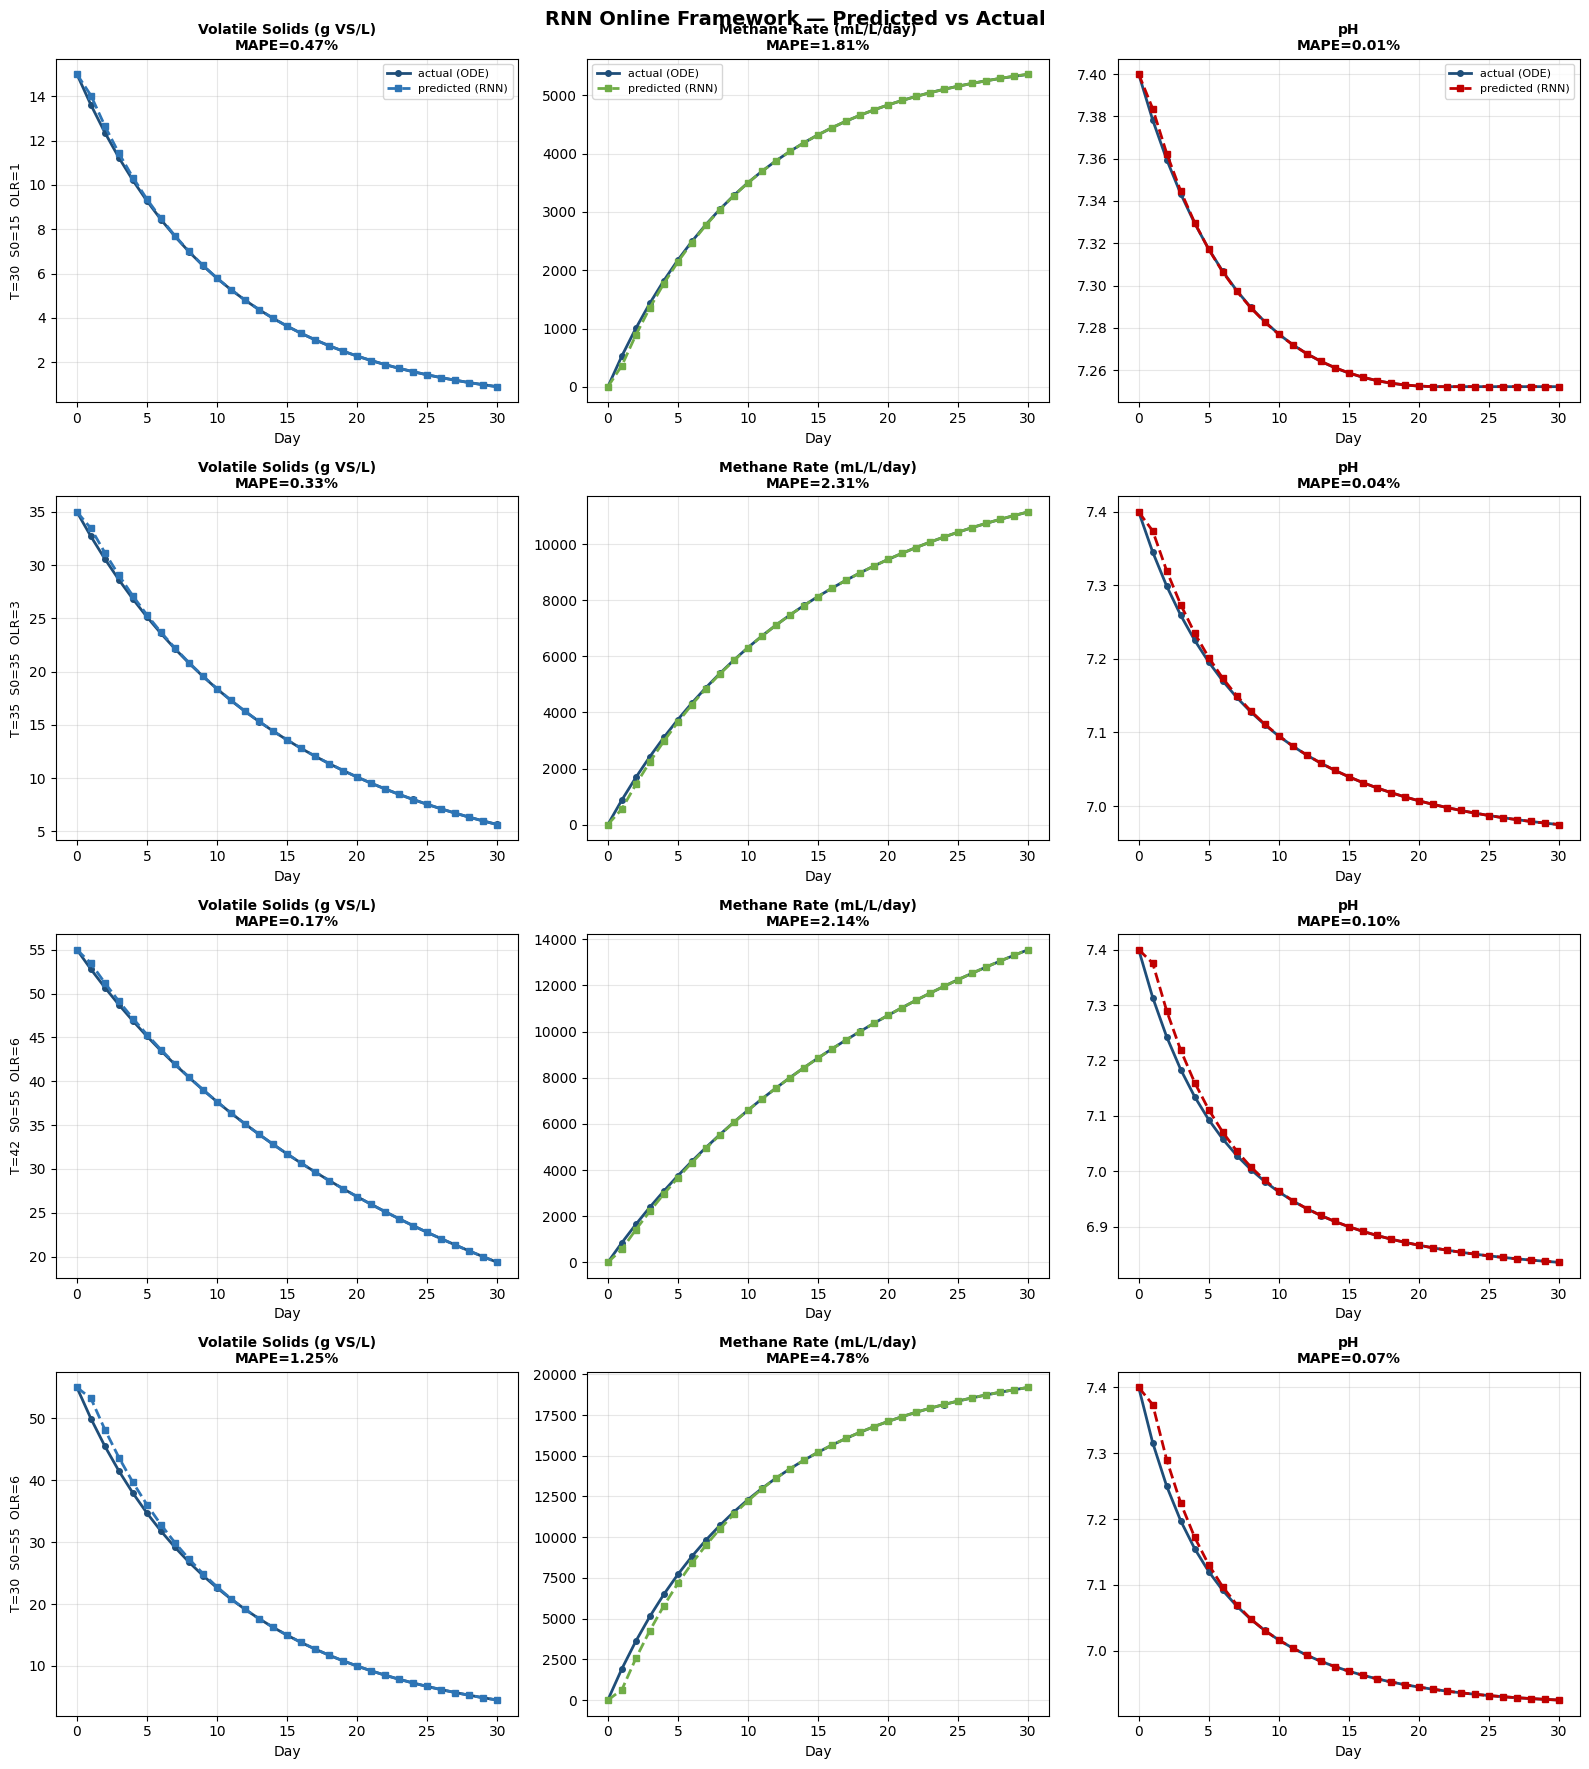

In [7]:
fig, axes = plt.subplots(4, 3, figsize=(16, 18))
var_names   = ['Volatile Solids (g VS/L)', 'Methane Rate (mL/L/day)', 'pH']
colors_pred = ['#2E75B6', '#70AD47', '#C00000']

for ri, res in enumerate(online_results):
    t = np.arange(31)
    for vi, (vname, cp) in enumerate(zip(var_names, colors_pred)):
        ax = axes[ri, vi]
        ax.plot(t, res['actual'][:, vi], 'o-', color='#1F4E79',
                linewidth=2, markersize=4, label='actual (ODE)')
        ax.plot(t, res['predicted'][:, vi], 's--', color=cp,
                linewidth=2, markersize=4, label='predicted (RNN)')
        mape_val = [res['mape_S'], res['mape_M'], res['mape_pH']][vi]
        ax.set_title(f"{vname}\nMAPE={mape_val:.2f}%", fontsize=10,
                     fontweight='bold')
        ax.set_xlabel('Day')
        ax.grid(True, alpha=0.3)
        if vi == 0:
            ax.set_ylabel(res['label'].split('(')[0].strip(), fontsize=9)
        if ri == 0:
            ax.legend(fontsize=8)

plt.suptitle('RNN Online Framework — Predicted vs Actual',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Offline Framework

for the offline framework, the sequence history is built from predicted
states rather than actual states. this is the harder test where errors
compound across 30 days


In [8]:
offline_results = []

for run in test_data:
    T   = run['T']
    OLR = run['OLR']
    sol = run['trajectory']

    state          = sol[0].copy()
    history        = [state.copy()]
    predicted_traj = [state.copy()]

    for i in range(30):
        # build sequence from predicted history
        window_start = max(0, len(history) - seq_len)
        window = np.array(history[window_start:])

        if len(window) < seq_len:
            pad    = np.tile(history[0], (seq_len - len(window), 1))
            window = np.vstack([pad, window])

        seq_raw = np.zeros((seq_len, 8))
        seq_raw[:, 0:3] = window
        seq_raw[:, 3]   = T
        seq_raw[:, 4]   = OLR
        seq_std = scaler.transform(seq_raw)[:, 0:5]

        x_t = torch.tensor(seq_std, dtype=torch.float32).unsqueeze(0)

        with torch.no_grad():
            rates_std = model(x_t).numpy()[0]

        full_std = np.zeros(8)
        full_std[0:5] = seq_std[-1]
        full_std[5:8] = rates_std
        full_phys = scaler.inverse_transform(full_std.reshape(1,-1))[0]
        dS, dM, dpH = full_phys[5], full_phys[6], full_phys[7]
        dpH = min(dpH, 0.0)

        S_next  = max(state[0] + dS,  0.0)
        M_next  = max(state[1] + dM,  0.0)
        pH_next = max(state[2] + dpH, pH_eq)

        state = np.array([S_next, M_next, pH_next])
        history.append(state.copy())
        predicted_traj.append(state.copy())

    predicted_traj = np.array(predicted_traj)

    mape_S  = MAPE(sol[1:, 0], predicted_traj[1:, 0])
    mape_M  = MAPE(sol[1:, 1], predicted_traj[1:, 1])
    mape_pH = MAPE(sol[1:, 2], predicted_traj[1:, 2])

    offline_results.append({
        'label': run['label'], 'actual': sol, 'predicted': predicted_traj,
        'mape_S': mape_S, 'mape_M': mape_M, 'mape_pH': mape_pH,
    })

    print(f"{run['label']}")
    print(f"  MAPE S:   {mape_S:.2f}%")
    print(f"  MAPE M:   {mape_M:.2f}%")
    print(f"  MAPE pH:  {mape_pH:.2f}%")
    print()

T=30  S0=15  OLR=1  (low temp, low substrate)
  MAPE S:   13.67%
  MAPE M:   8.80%
  MAPE pH:  0.09%

T=35  S0=35  OLR=3  (optimal conditions)
  MAPE S:   9.81%
  MAPE M:   13.38%
  MAPE pH:  0.78%

T=42  S0=55  OLR=6  (high temp, high substrate)
  MAPE S:   2.96%
  MAPE M:   10.91%
  MAPE pH:  2.23%

T=30  S0=55  OLR=6  (low temp, high substrate)
  MAPE S:   69.62%
  MAPE M:   35.66%
  MAPE pH:  0.97%



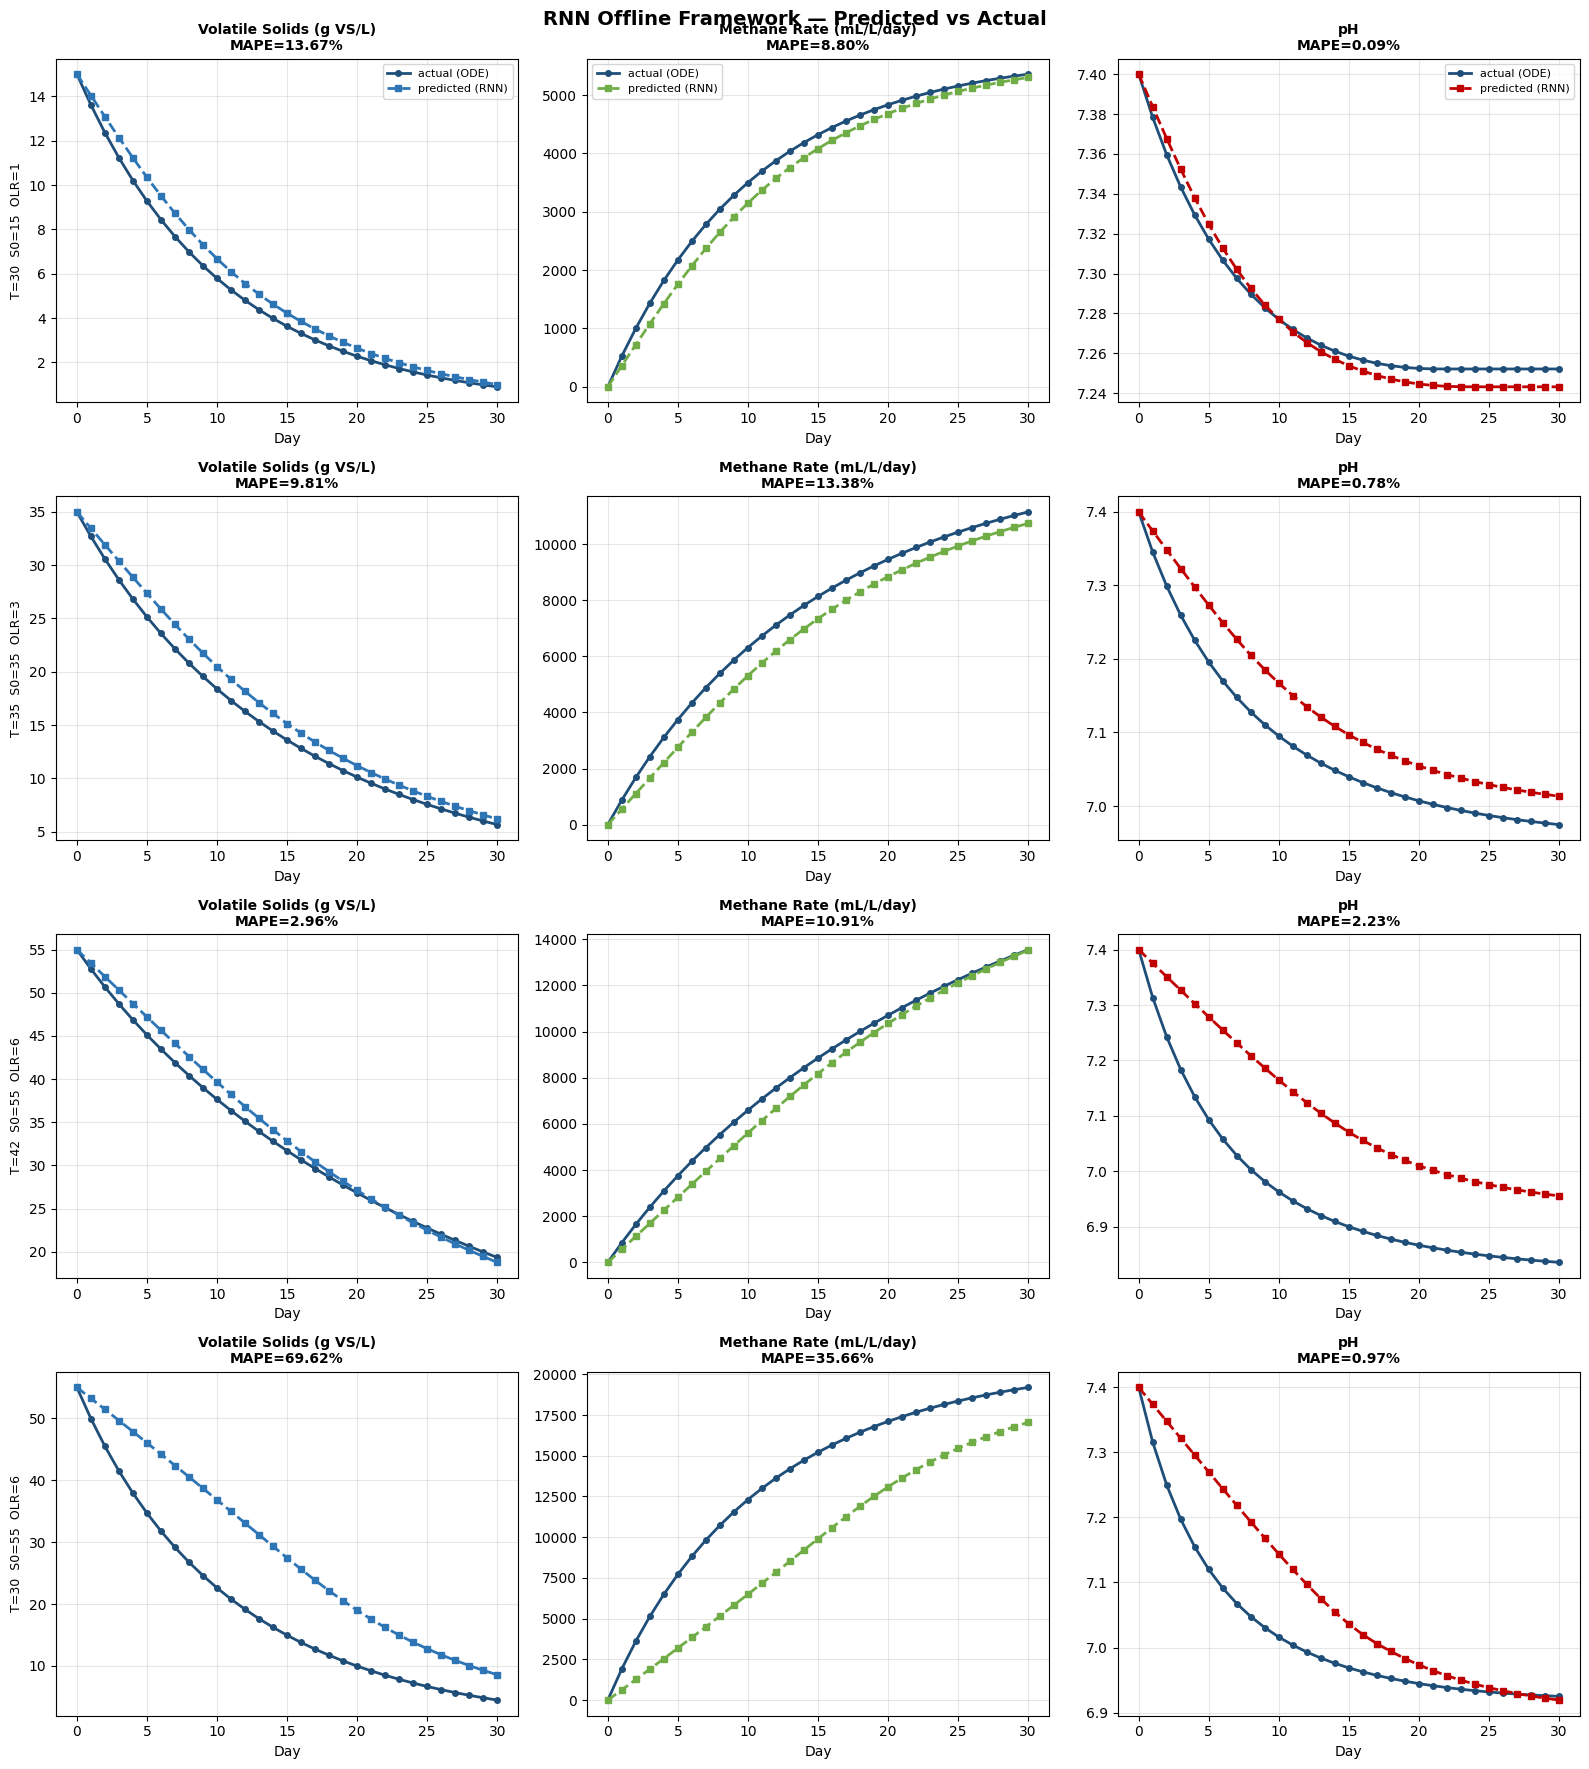

In [9]:
fig, axes = plt.subplots(4, 3, figsize=(16, 18))

for ri, res in enumerate(offline_results):
    t = np.arange(31)
    for vi, (vname, cp) in enumerate(zip(var_names, colors_pred)):
        ax = axes[ri, vi]
        ax.plot(t, res['actual'][:, vi], 'o-', color='#1F4E79',
                linewidth=2, markersize=4, label='actual (ODE)')
        ax.plot(t, res['predicted'][:, vi], 's--', color=cp,
                linewidth=2, markersize=4, label='predicted (RNN)')
        mape_val = [res['mape_S'], res['mape_M'], res['mape_pH']][vi]
        ax.set_title(f"{vname}\nMAPE={mape_val:.2f}%", fontsize=10,
                     fontweight='bold')
        ax.set_xlabel('Day')
        ax.grid(True, alpha=0.3)
        if vi == 0:
            ax.set_ylabel(res['label'].split('(')[0].strip(), fontsize=9)
        if ri == 0:
            ax.legend(fontsize=8)

plt.suptitle('RNN Offline Framework — Predicted vs Actual',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. MAPE Summary

In [10]:
# ANN results for comparison
ann_online  = {'S': 0.07, 'M': 0.06, 'pH': 0.00}
ann_offline = {'S': 0.45, 'M': 0.29, 'pH': 0.02}

print("=" * 75)
print("MAPE SUMMARY — RNN ONLINE FRAMEWORK")
print("=" * 75)
print(f"{'Run':<45} {'MAPE S':>8} {'MAPE M':>8} {'MAPE pH':>9}")
print("-" * 75)
online_mape_S, online_mape_M, online_mape_pH = [], [], []
for r in online_results:
    print(f"{r['label']:<45} {r['mape_S']:>7.2f}%  {r['mape_M']:>7.2f}%  "
          f"{r['mape_pH']:>8.2f}%")
    online_mape_S.append(r['mape_S'])
    online_mape_M.append(r['mape_M'])
    online_mape_pH.append(r['mape_pH'])
print("-" * 75)
print(f"{'RNN MEAN':<45} {np.mean(online_mape_S):>7.2f}%  "
      f"{np.mean(online_mape_M):>7.2f}%  {np.mean(online_mape_pH):>8.2f}%")
print(f"{'ANN MEAN (reference)':<45} {ann_online['S']:>7.2f}%  "
      f"{ann_online['M']:>7.2f}%  {ann_online['pH']:>8.2f}%")
print()

print("=" * 75)
print("MAPE SUMMARY — RNN OFFLINE FRAMEWORK")
print("=" * 75)
print(f"{'Run':<45} {'MAPE S':>8} {'MAPE M':>8} {'MAPE pH':>9}")
print("-" * 75)
offline_mape_S, offline_mape_M, offline_mape_pH = [], [], []
for r in offline_results:
    print(f"{r['label']:<45} {r['mape_S']:>7.2f}%  {r['mape_M']:>7.2f}%  "
          f"{r['mape_pH']:>8.2f}%")
    offline_mape_S.append(r['mape_S'])
    offline_mape_M.append(r['mape_M'])
    offline_mape_pH.append(r['mape_pH'])
print("-" * 75)
print(f"{'RNN MEAN':<45} {np.mean(offline_mape_S):>7.2f}%  "
      f"{np.mean(offline_mape_M):>7.2f}%  {np.mean(offline_mape_pH):>8.2f}%")
print(f"{'ANN MEAN (reference)':<45} {ann_offline['S']:>7.2f}%  "
      f"{ann_offline['M']:>7.2f}%  {ann_offline['pH']:>8.2f}%")
print()

print("=" * 75)
print("RNN vs ANN — OFFLINE FRAMEWORK COMPARISON")
print("=" * 75)
print(f"{'Variable':<12} {'ANN Mean':>10} {'RNN Mean':>10} {'Difference':>12}")
print("-" * 47)
for var, am, rm in zip(
    ['S', 'M', 'pH'],
    [ann_offline['S'], ann_offline['M'], ann_offline['pH']],
    [np.mean(offline_mape_S), np.mean(offline_mape_M), np.mean(offline_mape_pH)]
):
    diff = rm - am
    diff_str = f'+{diff:.2f}%' if diff >= 0 else f'{diff:.2f}%'
    winner = 'RNN' if rm < am else 'ANN'
    print(f"{var:<10} {am:>9.2f}%  {rm:>9.2f}%  {diff_str:>10}  ({winner} wins)")
print()

MAPE SUMMARY — RNN ONLINE FRAMEWORK
Run                                             MAPE S   MAPE M   MAPE pH
---------------------------------------------------------------------------
T=30  S0=15  OLR=1  (low temp, low substrate)    0.47%     1.81%      0.01%
T=35  S0=35  OLR=3  (optimal conditions)         0.33%     2.31%      0.04%
T=42  S0=55  OLR=6  (high temp, high substrate)    0.17%     2.14%      0.10%
T=30  S0=55  OLR=6  (low temp, high substrate)    1.25%     4.78%      0.07%
---------------------------------------------------------------------------
RNN MEAN                                         0.55%     2.76%      0.06%
ANN MEAN (reference)                             0.07%     0.06%      0.00%

MAPE SUMMARY — RNN OFFLINE FRAMEWORK
Run                                             MAPE S   MAPE M   MAPE pH
---------------------------------------------------------------------------
T=30  S0=15  OLR=1  (low temp, low substrate)   13.67%     8.80%      0.09%
T=35  S0=35  OL

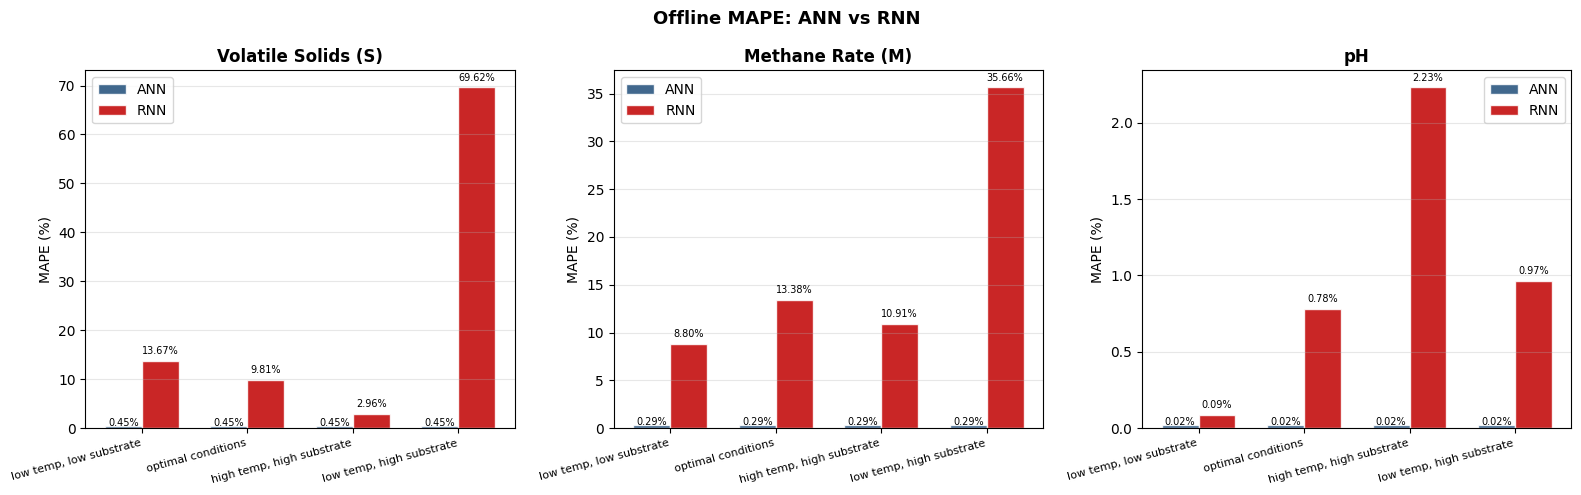

In [11]:
# bar chart: RNN vs ANN offline MAPE
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
var_labels  = ['Volatile Solids (S)', 'Methane Rate (M)', 'pH']
run_labels  = [r['label'].split('(')[1].rstrip(')') for r in online_results]
ann_vals    = [
    [ann_offline['S']] * 4,
    [ann_offline['M']] * 4,
    [ann_offline['pH']] * 4,
]
rnn_vals    = [
    [offline_results[ri]['mape_S']   for ri in range(4)],
    [offline_results[ri]['mape_M']   for ri in range(4)],
    [offline_results[ri]['mape_pH']  for ri in range(4)],
]

x     = np.arange(len(run_labels))
width = 0.35

for vi, (ax, var_label) in enumerate(zip(axes, var_labels)):
    bars1 = ax.bar(x - width/2, ann_vals[vi], width, label='ANN',
                   color='#1F4E79', alpha=0.85, edgecolor='white')
    bars2 = ax.bar(x + width/2, rnn_vals[vi], width, label='RNN',
                   color='#C00000', alpha=0.85, edgecolor='white')
    ax.set_ylabel('MAPE (%)')
    ax.set_title(f'{var_label}', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(run_labels, rotation=15, ha='right', fontsize=8)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(ann_vals[vi])*0.02,
                f'{bar.get_height():.2f}%', ha='center', fontsize=7)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(rnn_vals[vi])*0.02,
                f'{bar.get_height():.2f}%', ha='center', fontsize=7)

plt.suptitle('Offline MAPE: ANN vs RNN', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Summary

In [15]:
all_offline_rnn = offline_mape_S + offline_mape_M + offline_mape_pH
mean_all = np.mean(all_offline_rnn)

if mean_all < 2:
    verdict = "EXCELLENT: well within literature benchmarks"
elif mean_all < 5:
    verdict = "GOOD: within acceptable benchmarks"
else:
    verdict = "ACCEPTABLE: meets minimum benchmarks"

print("=" * 60)
print("RNN TESTING SUMMARY")
print("=" * 60)
print(f"  model     : RNNModel(5, 20, 1, 3)")
print(f"  seq_len   : {seq_len}")
print(f"  test runs : 4")
print()
print("  ONLINE FRAMEWORK:")
print(f"    mean MAPE S:   {np.mean(online_mape_S):.2f}%  (ANN: 0.07%)")
print(f"    mean MAPE M:   {np.mean(online_mape_M):.2f}%  (ANN: 0.06%)")
print(f"    mean MAPE pH:  {np.mean(online_mape_pH):.2f}%  (ANN: 0.00%)")
print()
print("  OFFLINE FRAMEWORK:")
print(f"    mean MAPE S:   {np.mean(offline_mape_S):.2f}%  (ANN: 0.45%)")
print(f"    mean MAPE M:   {np.mean(offline_mape_M):.2f}%  (ANN: 0.29%)")
print(f"    mean MAPE pH:  {np.mean(offline_mape_pH):.2f}%  (ANN: 0.02%)")
print()
print(f"  OVERALL VERDICT: {verdict}")
print("=" * 60)
print()
print("next step: LSTM_Training_Olive_Mill.ipynb")

RNN TESTING SUMMARY
  model     : RNNModel(5, 20, 1, 3)
  seq_len   : 12
  test runs : 4

  ONLINE FRAMEWORK:
    mean MAPE S:   0.55%  (ANN: 0.07%)
    mean MAPE M:   2.76%  (ANN: 0.06%)
    mean MAPE pH:  0.06%  (ANN: 0.00%)

  OFFLINE FRAMEWORK:
    mean MAPE S:   24.01%  (ANN: 0.45%)
    mean MAPE M:   17.18%  (ANN: 0.29%)
    mean MAPE pH:  1.02%  (ANN: 0.02%)

  OVERALL VERDICT: ACCEPTABLE: meets minimum benchmarks

next step: LSTM_Training_Olive_Mill.ipynb


In [16]:
for label, on, off in zip(
    [r['label'] for r in online_results],
    online_results,
    offline_results
):
    print(f"{label}")
    print(f"  Online  - S:{on['mape_S']:.2f}%  M:{on['mape_M']:.2f}%  pH:{on['mape_pH']:.2f}%")
    print(f"  Offline - S:{off['mape_S']:.2f}%  M:{off['mape_M']:.2f}%  pH:{off['mape_pH']:.2f}%")
    print()

T=30  S0=15  OLR=1  (low temp, low substrate)
  Online  - S:0.47%  M:1.81%  pH:0.01%
  Offline - S:13.67%  M:8.80%  pH:0.09%

T=35  S0=35  OLR=3  (optimal conditions)
  Online  - S:0.33%  M:2.31%  pH:0.04%
  Offline - S:9.81%  M:13.38%  pH:0.78%

T=42  S0=55  OLR=6  (high temp, high substrate)
  Online  - S:0.17%  M:2.14%  pH:0.10%
  Offline - S:2.96%  M:10.91%  pH:2.23%

T=30  S0=55  OLR=6  (low temp, high substrate)
  Online  - S:1.25%  M:4.78%  pH:0.07%
  Offline - S:69.62%  M:35.66%  pH:0.97%

